###Download Datasets

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


###Necessary Libraries

In [18]:
import os
import cv2
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

from skimage import color
from skimage.feature import hog
from skimage import exposure

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

###Dataset Creation

In [3]:
data_dir = os.path.join(path,"chest_xray/train")

normal_df = pd.DataFrame(columns=['filepaths', 'labels'])
pneumonia_df = pd.DataFrame(columns=['filepaths', 'labels'])

normal_label = 0
pneumonia_label = 1

normal_files = os.listdir(os.path.join(data_dir, "NORMAL"))
pneumonia_files = os.listdir(os.path.join(data_dir, "PNEUMONIA"))

normal_df['filepaths'] = [os.path.join(data_dir, "NORMAL", filename) for filename in normal_files]
normal_df['labels'] = normal_label

pneumonia_df['filepaths'] = [os.path.join(data_dir, "PNEUMONIA", filename) for filename in pneumonia_files]
pneumonia_df['labels'] = pneumonia_label


In [4]:
combined_df = pd.concat([normal_df, pneumonia_df], ignore_index=True)

label_counts = combined_df['labels'].value_counts()
print("\nLabel Counts:")
print(label_counts)


Label Counts:
labels
1    3875
0    1341
Name: count, dtype: int64


###Image Augmentation and Processing

In [5]:
def augment(img):
    datagen = ImageDataGenerator(
        shear_range=0.2,
        zoom_range=0.2,
    )

    img = np.expand_dims(img, 0)
    augmented_images = datagen.flow(img)

    return augmented_images[0]

def process_images(filepaths, image_size=(128, 128)):
    images = []
    for path in filepaths:
        try:
            img = cv2.imread(path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, image_size)
            img = img.astype(np.float32) / 255.0

            augmented_img = augment(img)
            augmented_img = np.squeeze(augmented_img, axis=0)

            images.append(augmented_img)
        except Exception as e:
            print(f"Error processing image at path: {path}")
            print(f"Details: {str(e)}")

    return tf.convert_to_tensor(images)

normal_tensor = process_images(normal_df['filepaths'].values)
pneumonia_tensor = process_images(pneumonia_df['filepaths'].values)

print("Normal Tensor Shape:", normal_tensor.shape)
print("Pneumonia Tensor Shape:", pneumonia_tensor.shape)

Normal Tensor Shape: (1341, 128, 128, 3)
Pneumonia Tensor Shape: (3875, 128, 128, 3)


###Data Splitting and Dataset Preparation

In [6]:
# Create label arrays for normal and pneumonia cases
normal_labels = np.zeros(len(normal_tensor), dtype=np.int64)
pneumonia_labels = np.ones(len(pneumonia_tensor), dtype=np.int64)

# Concatenate labels to form a single label array
labels = np.concatenate((normal_labels, pneumonia_labels), axis=0)

# Concatenate processed image tensors
images = np.concatenate((normal_tensor, pneumonia_tensor), axis=0)

# Split the dataset into training and testing sets, ensuring stratified sampling
train_images, test_images, train_labels, test_labels = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels)

# Create TensorFlow datasets from the split data
train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
test_dataset = tf.data.Dataset.from_tensor_slices((test_images, test_labels))

In [7]:
train_dataset_cardinality = train_dataset.cardinality()
print("Number of elements in train_dataset:", train_dataset_cardinality)

test_dataset_cardinality = test_dataset.cardinality()
print("Number of elements in test_dataset:", test_dataset_cardinality)

Number of elements in train_dataset: tf.Tensor(4172, shape=(), dtype=int64)
Number of elements in test_dataset: tf.Tensor(1044, shape=(), dtype=int64)


In [8]:
# Define the batch size for training and evaluation
batch_size = 32

# Shuffle and batch the training dataset
train_data = train_dataset.shuffle(10000).batch(batch_size)

# Batch the test dataset (shuffling is typically not needed for test data)
test_data = test_dataset.batch(batch_size)

In [9]:
for image,label in train_data.take(1):
    print(image.shape)

(32, 128, 128, 3)


###Data Visualization

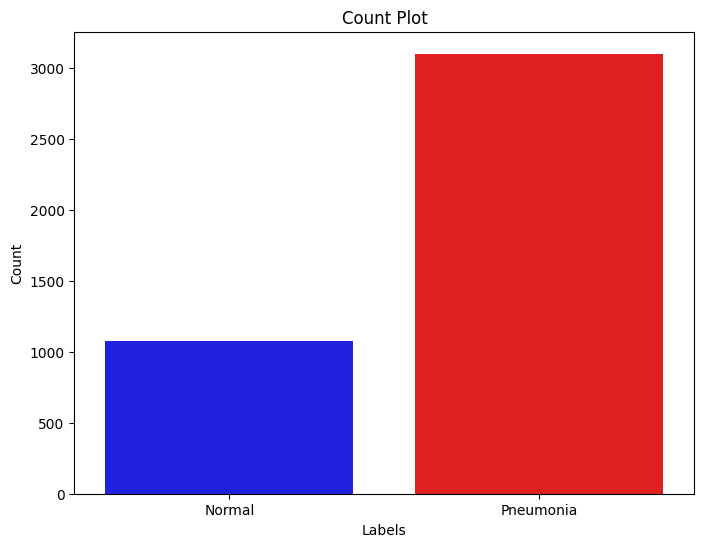

In [10]:
plt.figure(figsize=(8, 6))
sns.countplot(
    x=train_labels,
    hue=train_labels,
    palette={0: 'blue', 1: 'red'},   # Normal = blue, Pneumonia = red
    legend=False
)
plt.xlabel('Labels')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Normal', 'Pneumonia'])
plt.title('Count Plot')
plt.show()

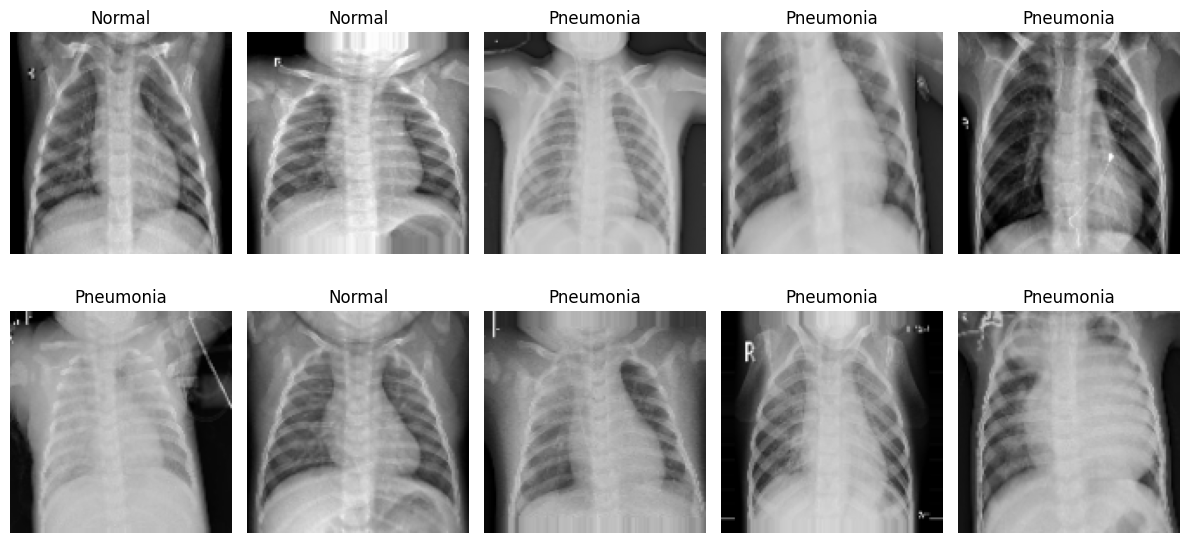

In [11]:
label_names = ['Normal', 'Pneumonia']

def plot_images(images, labels, rows=2, cols=5):
    plt.figure(figsize=(12, 6))
    for i in range(rows * cols):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i])
        plt.title(label_names[labels[i]])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_images(train_images[:10], train_labels[:10])

###Data Oversampling

In [12]:
normal_indices = np.where(train_labels == 0)[0]
pneumonia_indices = np.where(train_labels == 1)[0]

# Count the number of samples for each class
normal_count = len(normal_indices)
pneumonia_count = len(pneumonia_indices)

print(f"Original Normal count: {normal_count}")
print(f"Original Pneumonia count: {pneumonia_count}")

# Calculate the number of additional 'NORMAL' samples required
num_to_oversample = pneumonia_count - normal_count

# Randomly select additional 'NORMAL' samples with replacement
if num_to_oversample > 0:
    oversampled_indices = np.random.choice(normal_indices, size=num_to_oversample, replace=True)

    # Get the oversampled images and labels
    oversampled_normal_images = train_images[oversampled_indices]
    oversampled_normal_labels = train_labels[oversampled_indices]

    # Concatenate the oversampled 'NORMAL' samples with the original training data
    train_images_oversampled = np.concatenate((train_images, oversampled_normal_images), axis=0)
    train_labels_oversampled = np.concatenate((train_labels, oversampled_normal_labels), axis=0)
else:
    train_images_oversampled = train_images
    train_labels_oversampled = train_labels

# Verify the new class distribution
new_normal_count = np.sum(train_labels_oversampled == 0)
new_pneumonia_count = np.sum(train_labels_oversampled == 1)

print(f"\nNew Normal count after oversampling: {new_normal_count}")
print(f"New Pneumonia count after oversampling: {new_pneumonia_count}")

# Update the train_data by creating a new TensorFlow dataset
train_dataset_oversampled = tf.data.Dataset.from_tensor_slices((train_images_oversampled, train_labels_oversampled))
train_data = train_dataset_oversampled.shuffle(10000).batch(batch_size)

print(f"Number of elements in oversampled train_dataset: {train_dataset_oversampled.cardinality()}")

Original Normal count: 1073
Original Pneumonia count: 3099

New Normal count after oversampling: 3099
New Pneumonia count after oversampling: 3099
Number of elements in oversampled train_dataset: 6198


###Hog Feature Extraction

In [16]:
def compute_hog_features(images):
    hog_features = []
    for image in images:
        # Convert image to grayscale for HOG computation
        gray_image = color.rgb2gray(image)
        # Compute HOG features (fd) and optionally a visualization (hog_image)
        fd, hog_image = hog(gray_image, orientations=8, pixels_per_cell=(4, 4),
                            cells_per_block=(1, 1), visualize=True)

        # Rescale HOG image for better visualization
        hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
        hog_features.append(fd)
    return np.array(hog_features)

train_hog_features = compute_hog_features(train_images)
test_hog_features = compute_hog_features(test_images)

###Random Forest Classification and Evaluation

In [19]:
random_forest = RandomForestClassifier(n_estimators=1000, random_state=42)
random_forest.fit(train_hog_features, train_labels)

RandomForestClassifier(n_estimators=1000, random_state=42)

In [20]:
predictions = random_forest.predict(test_hog_features)

accuracy = accuracy_score(test_labels, predictions)
print("Accuracy: {:.2f}%".format(accuracy * 100))

report = classification_report(test_labels, predictions)
print("Classification Report:\n", report)

Accuracy: 86.69%
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.56      0.68       268
           1       0.86      0.97      0.92       776

    accuracy                           0.87      1044
   macro avg       0.87      0.77      0.80      1044
weighted avg       0.87      0.87      0.86      1044



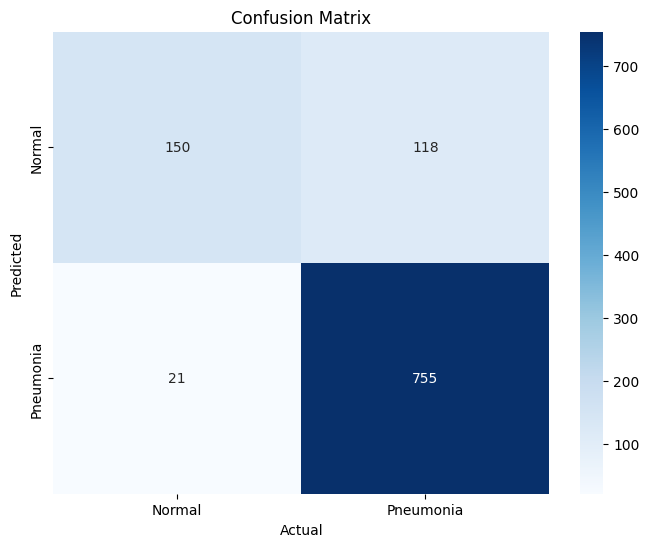

In [21]:
conf_matrix = confusion_matrix(test_labels, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Confusion Matrix')
plt.show()